In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
# Cell 2: Load Data
df = pd.read_csv('/kaggle/input/datasets/akashdogra/cic-iot-2023/part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv')
print(f"Shape: {df.shape}")
print(df.columns.tolist())
df.head()

Shape: (238687, 47)
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,54.00,6.00,64.00,0.329807,0.329807,0.0,1.0,0.0,1.0,...,0.000000,54.00,8.334383e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-RSTFINFlood
1,0.000000,57.04,6.33,64.00,4.290556,4.290556,0.0,0.0,0.0,0.0,...,2.822973,57.04,8.292607e+07,9.5,10.464666,4.010353,160.987842,0.05,141.55,DoS-TCP_Flood
2,0.000000,0.00,1.00,64.00,33.396799,33.396799,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.312799e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood
3,0.328175,76175.00,17.00,64.00,4642.133010,4642.133010,0.0,0.0,0.0,0.0,...,0.000000,50.00,8.301570e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DoS-UDP_Flood
4,0.117320,101.73,6.11,65.91,6.202211,6.202211,0.0,0.0,1.0,0.0,...,23.113111,57.88,8.297300e+07,9.5,11.346876,32.716243,3016.808286,0.19,141.55,DoS-SYN_Flood


In [8]:
# Cell 3: Find label column & EDA
print(df.dtypes.value_counts())
print("\nLast 5 columns (likely label):")
print(df.iloc[:, -5:].nunique())

float64    46
object      1
Name: count, dtype: int64

Last 5 columns (likely label):
Radius        41062
Covariance    41282
Variance        178
Weight           97
label            34
dtype: int64


label
DDoS-ICMP_Flood            36554
DDoS-UDP_Flood             27626
DDoS-TCP_Flood             23149
DDoS-PSHACK_Flood          21210
DDoS-SYN_Flood             20739
DDoS-RSTFINFlood           20669
DDoS-SynonymousIP_Flood    18189
DoS-UDP_Flood              16957
DoS-TCP_Flood              13630
DoS-SYN_Flood              10275
BenignTraffic               5600
Mirai-greeth_flood          5016
Mirai-udpplain              4661
Mirai-greip_flood           3758
DDoS-ICMP_Fragmentation     2377
MITM-ArpSpoofing            1614
DDoS-ACK_Fragmentation      1505
DDoS-UDP_Fragmentation      1484
DNS_Spoofing                 925
Recon-HostDiscovery          697
Recon-OSScan                 517
Recon-PortScan               430
DoS-HTTP_Flood               414
VulnerabilityScan            210
DDoS-HTTP_Flood              169
DDoS-SlowLoris               106
DictionaryBruteForce          63
SqlInjection                  31
BrowserHijacking              30
CommandInjection              28
Back

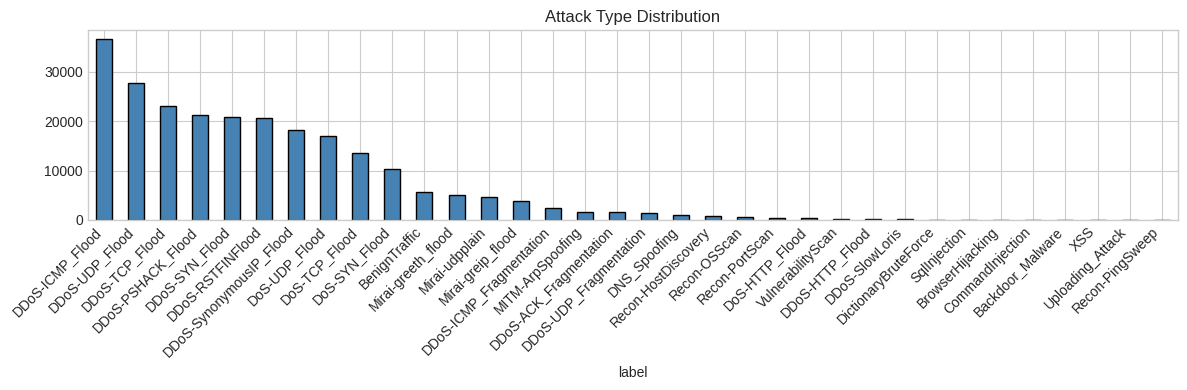

In [9]:
# Cell 4: Set label column (update after Cell 3 output)
label_col = 'label'  # ← update if different

print(df[label_col].value_counts())

# Distribution plot
df[label_col].value_counts().plot(kind='bar', figsize=(12,4), color='steelblue', edgecolor='black')
plt.title('Attack Type Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()

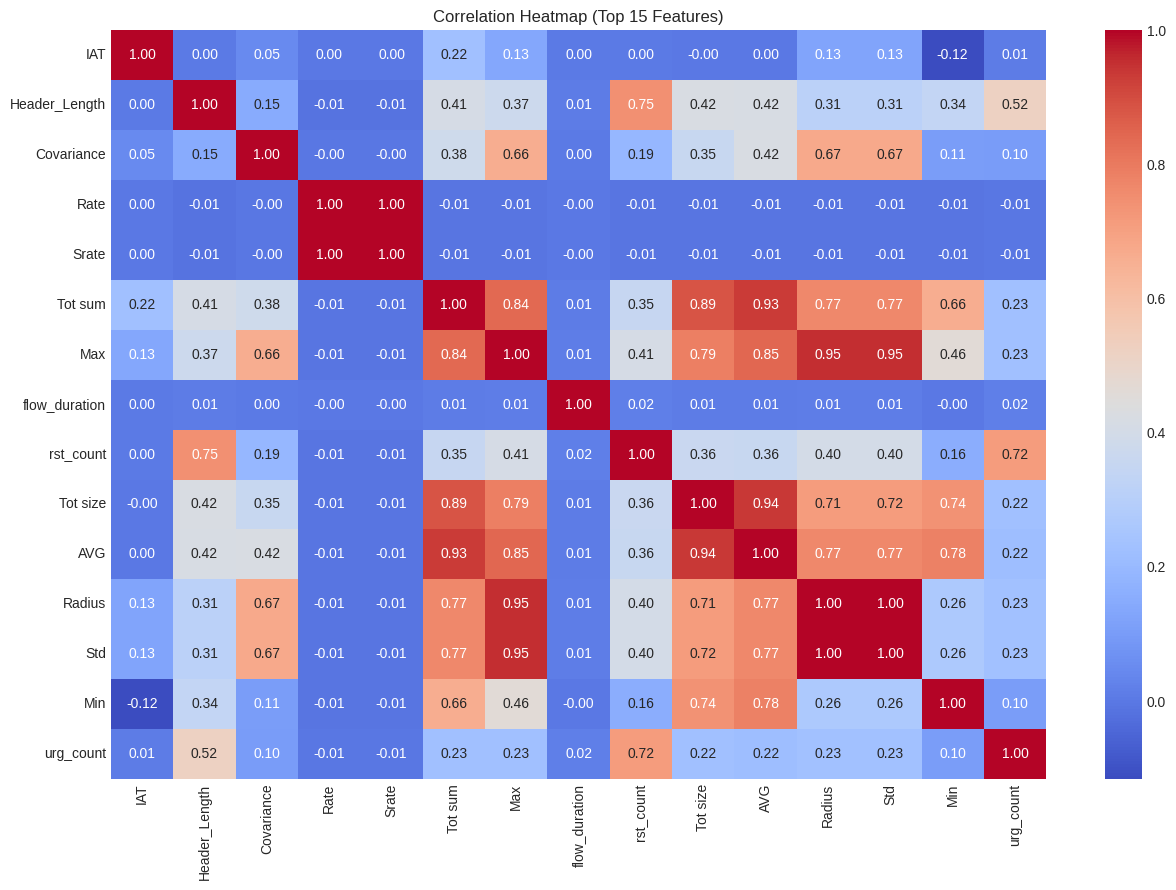

In [10]:
# Cell 5: Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
top_feats = numeric_df.var().nlargest(15).index
plt.figure(figsize=(13,9))
sns.heatmap(numeric_df[top_feats].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Top 15 Features)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [11]:
# Cell 6: Preprocessing
df_clean = df.copy()
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean.drop_duplicates(inplace=True)
num_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

le = LabelEncoder()
y = le.fit_transform(df_clean[label_col])
class_names = le.classes_

X = df_clean.drop(columns=[label_col], errors='ignore').select_dtypes(include=[np.number])
X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape} | Classes: {len(class_names)}")

Train: (190949, 46) | Test: (47738, 46) | Classes: 34


In [13]:
# Cell 7: Train Models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=15, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=300, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'model': model, 'accuracy': acc, 'f1': f1, 'y_pred': y_pred}
    print(f"{name}: Acc={acc:.4f} | F1={f1:.4f}")

Random Forest: Acc=0.9908 | F1=0.9901
Decision Tree: Acc=0.9885 | F1=0.9881
Logistic Regression: Acc=0.8118 | F1=0.7803


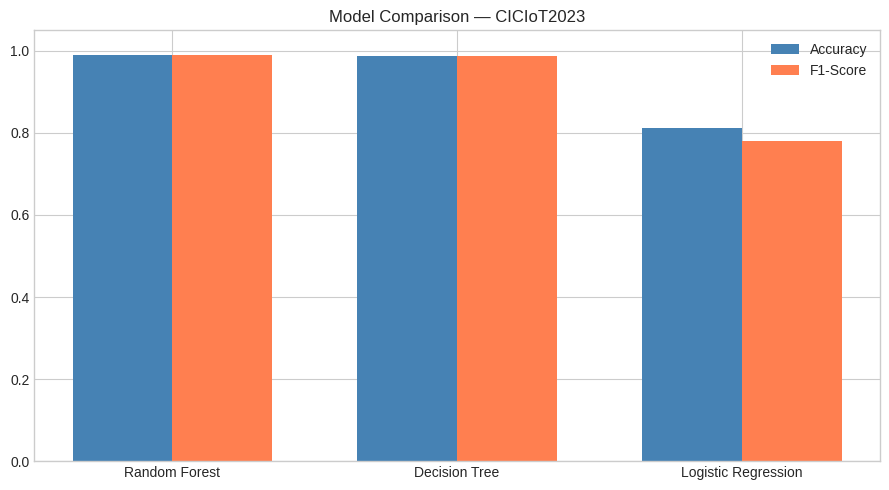

In [14]:
# Cell 8: Model Comparison Chart
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
f1s  = [results[n]['f1'] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x-0.175, accs, 0.35, label='Accuracy', color='steelblue')
ax.bar(x+0.175, f1s,  0.35, label='F1-Score',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1.05); ax.legend()
ax.set_title('Model Comparison — CICIoT2023')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

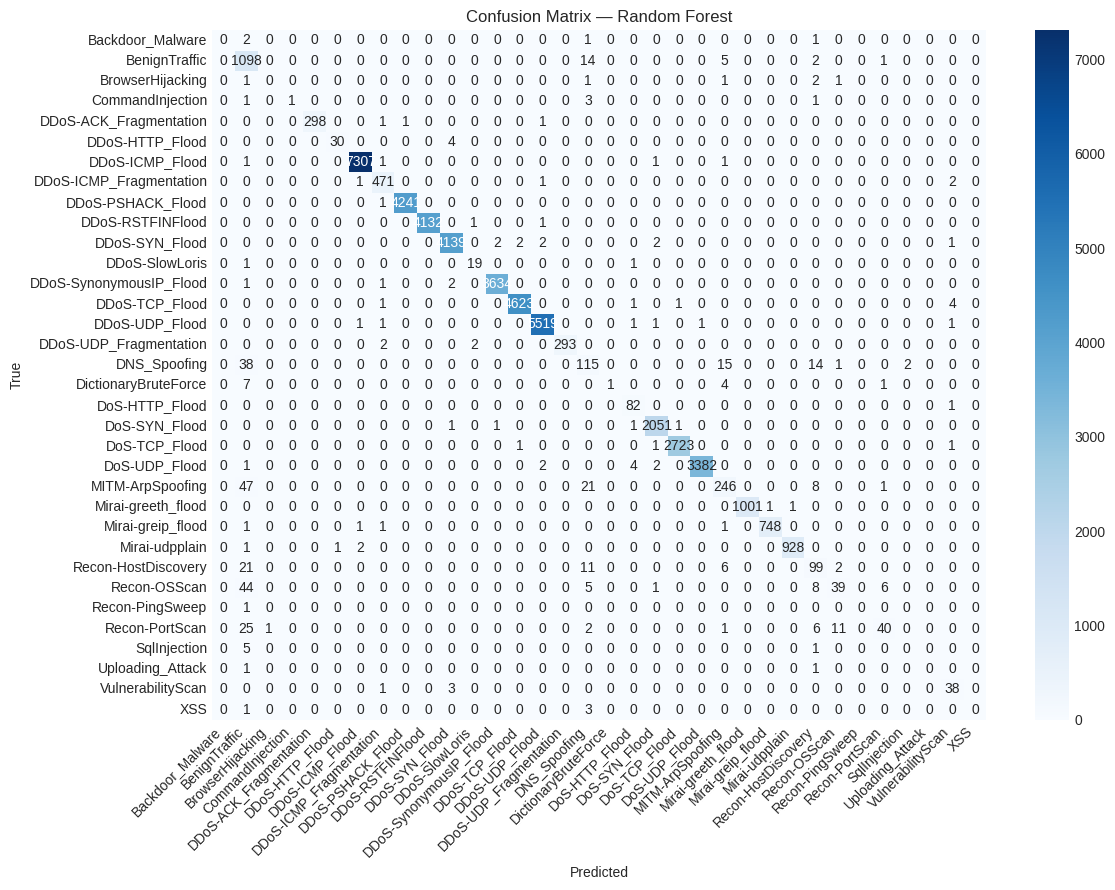

In [15]:
# Cell 9: Confusion Matrix (best model)
best = max(results, key=lambda n: results[n]['f1'])
cm = confusion_matrix(y_test, results[best]['y_pred'])
plt.figure(figsize=(12,9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best}')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

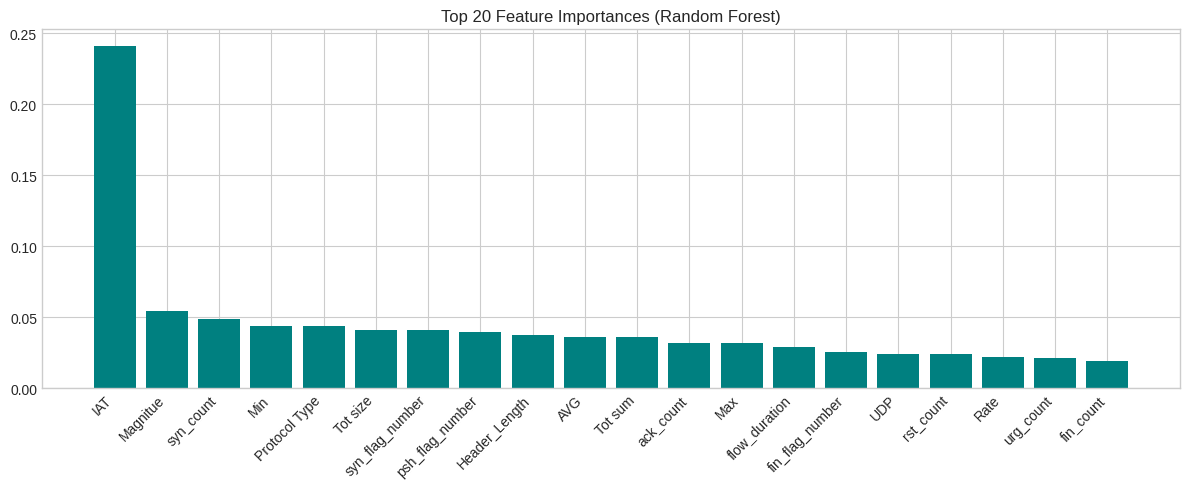


=== FINAL SUMMARY ===
Random Forest          | Acc: 0.9908 | F1: 0.9901
Decision Tree          | Acc: 0.9885 | F1: 0.9881
Logistic Regression    | Acc: 0.8118 | F1: 0.7803


In [16]:
# Cell 10: Feature Importance
rf = results['Random Forest']['model']
top_idx = np.argsort(rf.feature_importances_)[::-1][:20]
plt.figure(figsize=(12,5))
plt.bar(range(20), rf.feature_importances_[top_idx], color='teal')
plt.xticks(range(20), X.columns[top_idx], rotation=45, ha='right')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\n=== FINAL SUMMARY ===")
for n in results:
    print(f"{n:22s} | Acc: {results[n]['accuracy']:.4f} | F1: {results[n]['f1']:.4f}")